# NB03 — N-Grams and Context  |  Claude Assisted
### NLP Workshop Series: From Bag-of-Words to Embeddings

---

## Workshop Roadmap

```
+------+--------------------------------------------+------------------+
|  NLP Workshop: From Bag-of-Words to Embeddings                      |
+------+--------------------------------------------+------------------+
|  NB  |  Title                                     |  Status          |
+------+--------------------------------------------+------------------+
|  01  |  Text Preprocessing & Bag-of-Words         |  Completed       |
|  02  |  TF-IDF and Ranked Retrieval               |  Completed       |
|  03  |  N-Grams and Context Windows               |  << YOU ARE HERE |
|  04  |  Word Co-occurrence and PMI                |  Coming up       |
|  05  |  Introduction to Word Embeddings (Word2Vec)|  Coming up       |
|  06  |  Working with Pre-trained Embeddings       |  Coming up       |
|  07  |  Sentence Embeddings and Semantic Search   |  Coming up       |
|  08  |  Putting It All Together: Mini Search Eng. |  Coming up       |
+------+--------------------------------------------+------------------+
```

---

## What We Learned in NB01 and NB02

**NB01 — Text Preprocessing & Bag-of-Words**
- Built a text preprocessing pipeline: lowercase, remove punctuation, tokenize, remove stopwords
- Constructed a vocabulary from all 6,236 Quran verses (Daryabadi translation)
- Represented each verse as a sparse Bag-of-Words (BoW) count vector
- Used cosine similarity for basic keyword search

**NB02 — TF-IDF and Ranked Retrieval**
- Identified the flaw in raw BoW: common words dominate similarity scores unfairly
- Learned TF-IDF: rewards words that are frequent in a document but rare across the corpus
- Built a ranked search engine using TF-IDF vectors and cosine similarity
- Saw clear improvements in retrieval quality over plain BoW

---

## The Problem That Remains

Both BoW and TF-IDF share a fundamental blind spot: **word order is completely ignored**.

Every document is treated as a *bag* — a multiset of words with no notion of sequence, position, or neighbourhood. This means:

- `"not good"` and `"very good"` produce the same vector after stopword removal (only `"good"` survives)
- `"man bites dog"` and `"dog bites man"` are indistinguishable
- Phrases like `"day of judgement"` are broken into separate unrelated tokens

N-grams are the first — and most widely used — solution to this problem.

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain why word order matters and how BoW/TF-IDF lose it
2. Define n-grams (unigrams, bigrams, trigrams) with concrete examples
3. Extract n-grams manually using NLTK
4. Build n-gram vectorizers with scikit-learn's `CountVectorizer`
5. Build and query an n-gram search engine on the Quran corpus
6. Construct a simple bigram language model
7. Articulate the limitations of n-grams and why embeddings are the next step

---

## Section 1 — The Word Order Problem

Before we introduce n-grams, let us make the problem concrete.

### Why Order Matters

Natural language meaning is encoded not just in *which* words appear, but in *how they are arranged*.

Consider these two pairs:

**Pair A — Sentiment reversal**
```
Sentence 1:  "not good"   ->  after stopword removal:  ["good"]
Sentence 2:  "very good"  ->  after stopword removal:  ["good"]
```
Both sentences collapse to the identical vector `{good: 1}`. A BoW model cannot distinguish praise from criticism.

**Pair B — Agent/Patient reversal**
```
Sentence 1:  "man bites dog"  ->  tokens: {man, bites, dog}
Sentence 2:  "dog bites man"  ->  tokens: {man, bites, dog}  (identical!)
```
The subject and object are swapped, giving a completely different meaning, yet both have the same unigram vector.

These failures motivate n-grams: instead of single tokens, we use *sequences* of adjacent tokens as features.

In [1]:
# ============================================================
# Section 1: Demonstrating the Word Order Problem
# We vectorize both pairs and show they produce identical vectors
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# --- Pair A: sentiment reversal ---
pair_a = ["not good", "very good"]

# Build a unigram vectorizer (default: removes English stopwords)
vec_a = CountVectorizer(stop_words='english')
X_a = vec_a.fit_transform(pair_a)

print("=== Pair A: 'not good' vs 'very good' (unigram BoW) ===")
df_a = pd.DataFrame(X_a.toarray(), columns=vec_a.get_feature_names_out(),
                    index=["not good", "very good"])
print(df_a)
print()
print("Are the vectors identical?", (X_a[0] - X_a[1]).nnz == 0)
print()

# --- Pair B: agent/patient reversal ---
pair_b = ["man bites dog", "dog bites man"]

vec_b = CountVectorizer()   # no stopword removal so we keep all tokens
X_b = vec_b.fit_transform(pair_b)

print("=== Pair B: 'man bites dog' vs 'dog bites man' (unigram BoW) ===")
df_b = pd.DataFrame(X_b.toarray(), columns=vec_b.get_feature_names_out(),
                    index=["man bites dog", "dog bites man"])
print(df_b)
print()
print("Are the vectors identical?", (X_b[0] - X_b[1]).nnz == 0)
print()
print("Conclusion: Unigram BoW cannot tell these sentences apart.")
print("N-grams solve this by treating word SEQUENCES as features.")

=== Pair A: 'not good' vs 'very good' (unigram BoW) ===
           good
not good      1
very good     1

Are the vectors identical? True

=== Pair B: 'man bites dog' vs 'dog bites man' (unigram BoW) ===
               bites  dog  man
man bites dog      1    1    1
dog bites man      1    1    1

Are the vectors identical? True

Conclusion: Unigram BoW cannot tell these sentences apart.
N-grams solve this by treating word SEQUENCES as features.


### The Stopword Trap -- A Critical Warning

Before we celebrate n-grams as a fix for word order, we need to confront a serious problem.

Recall from NB01 that our preprocessing pipeline removes stopwords. The NLTK English stopword list includes the word **`not`**.

This means:

| Sentence | After stopword removal | Bigrams available? |
|---|---|---|
| `"this movie is not good"` | `"movie good"` | `not_good` is **gone** |
| `"this movie is very good"` | `"movie good"` | `very_good` is **gone** |

**The stopword removal happens BEFORE bigram extraction.**
So by the time `CountVectorizer` tries to build the bigram `not_good`, the word `not` has already been deleted.

> **Key insight:** N-grams do not automatically fix negation if your preprocessing pipeline already destroyed the negation signal. This is one of the most common mistakes students make when applying n-grams.

The code cell below demonstrates this concretely.

In [2]:
# Stopword Trap Demonstration
# Shows that bigrams cannot rescue negation that preprocessing already destroyed

import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

english_stopwords = set(stopwords.words('english'))

sent_a = 'this movie is not good'
sent_b = 'this movie is very good'

# Step 1: Show raw bigrams BEFORE preprocessing (stopwords kept)
def get_bigrams_raw(text):
    tokens = text.lower().split()
    return [tokens[i] + '_' + tokens[i+1] for i in range(len(tokens)-1)]

print('RAW BIGRAMS (before preprocessing):')
print('  Sentence A:', get_bigrams_raw(sent_a))
print('  Sentence B:', get_bigrams_raw(sent_b))
print('  --> not_good and very_good are DIFFERENT bigrams')

# Step 2: Apply preprocessing (removes stopwords including not, is, very)
def preprocess_simple(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in english_stopwords and len(t) > 1]
    return ' '.join(tokens)

proc_a = preprocess_simple(sent_a)
proc_b = preprocess_simple(sent_b)

print()
print('AFTER PREPROCESSING (stopwords removed):')
print('  Sentence A:', repr(proc_a))
print('  Sentence B:', repr(proc_b))
print('  --> Both reduce to nearly identical tokens!')

# Step 3: Build bigram vectorizer on preprocessed text
cv_bigram = CountVectorizer(ngram_range=(1, 2))
vecs = cv_bigram.fit_transform([proc_a, proc_b])

sim_after = cosine_similarity(vecs[0], vecs[1])[0][0]

print()
print('BIGRAM VECTORIZER ON PREPROCESSED TEXT:')
print('  Vocabulary:', cv_bigram.get_feature_names_out().tolist())
print('  Cosine similarity between A and B:', round(sim_after, 4))
print()
print('CONCLUSION:')
print('  The bigram not_good never exists because not was removed as a stopword.')
print('  N-grams only help with word order AFTER preprocessing is done.')
print('  If preprocessing destroys the signal, n-grams cannot recover it.')
print()
print('FIX OPTIONS:')
print('  1. Remove not from the stopword list for sentiment-sensitive tasks')
print('  2. Use character n-grams (FastText -- NB05) which work at subword level')
print('  3. Use sentence embeddings (NB06) which encode full sentence meaning')


RAW BIGRAMS (before preprocessing):
  Sentence A: ['this_movie', 'movie_is', 'is_not', 'not_good']
  Sentence B: ['this_movie', 'movie_is', 'is_very', 'very_good']
  --> not_good and very_good are DIFFERENT bigrams

AFTER PREPROCESSING (stopwords removed):
  Sentence A: 'movie good'
  Sentence B: 'movie good'
  --> Both reduce to nearly identical tokens!

BIGRAM VECTORIZER ON PREPROCESSED TEXT:
  Vocabulary: ['good', 'movie', 'movie good']
  Cosine similarity between A and B: 1.0

CONCLUSION:
  The bigram not_good never exists because not was removed as a stopword.
  N-grams only help with word order AFTER preprocessing is done.
  If preprocessing destroys the signal, n-grams cannot recover it.

FIX OPTIONS:
  1. Remove not from the stopword list for sentiment-sensitive tasks
  2. Use character n-grams (FastText -- NB05) which work at subword level
  3. Use sentence embeddings (NB06) which encode full sentence meaning


---

## Section 2 — What Are N-Grams?

An **n-gram** is a contiguous sequence of *n* tokens drawn from a text.

The term comes from the Greek letter *n* (representing any positive integer) combined with *gram* (meaning a written unit).

---

### The Three Most Common Cases

| Name      | N | Description                          | Example from Quran                          |
|-----------|---|--------------------------------------|---------------------------------------------|
| Unigram   | 1 | Single word — what BoW already uses  | `allah`, `mercy`, `guidance`                |
| Bigram    | 2 | Pair of adjacent words               | `allah most`, `day judgement`, `not good`   |
| Trigram   | 3 | Triple of adjacent words             | `day last judgement`, `allah merciful wise` |

---

### Sliding Window Illustration

Given the text: `"and allah is most forgiving"`

**Unigrams (window size = 1)**
```
[and] [allah] [is] [most] [forgiving]
```

**Bigrams (window size = 2, step = 1)**
```
Position:  1          2           3          4
           [and allah] [allah is] [is most] [most forgiving]
            ^^^^^^^^^^  ^^^^^^^^^  ^^^^^^^^  ^^^^^^^^^^^^^^^  <- window slides by 1
```

**Trigrams (window size = 3, step = 1)**
```
Position:  1                   2                  3
           [and allah is]  [allah is most]  [is most forgiving]
            ^^^^^^^^^^^^^   ^^^^^^^^^^^^^^^  ^^^^^^^^^^^^^^^^^^  <- window slides by 1
```

For a text with *T* tokens:
- Number of unigrams = T
- Number of bigrams  = T - 1
- Number of trigrams = T - 2
- Number of n-grams  = T - (n - 1)

---

### When to Use Each N

| Setting               | Best choice         | Reason                                                       |
|-----------------------|---------------------|--------------------------------------------------------------|
| Short snippets, tweets| Unigrams only       | Not enough text for reliable higher-order statistics         |
| Document retrieval    | Unigrams + bigrams  | Balances coverage with phrase sensitivity                    |
| Sentiment analysis    | Unigrams + bigrams  | Captures negation (`not good`) and intensifiers (`very bad`) |
| Named entity detection| Bigrams + trigrams  | Proper names often span 2-3 tokens (`ibn kathir`, `abu bakr`)|
| Very large corpus     | Trigrams or higher  | Sparsity is less of a problem with enough data               |

In practice, `ngram_range=(1,2)` — unigrams plus bigrams — is the most commonly used setting in industry.

---

## Section 3 — Extracting N-Grams Manually with NLTK

Before relying on scikit-learn's automated vectorizers, we extract n-grams manually using NLTK.
This gives us full control and visibility into the process.

In [3]:
# ============================================================
# Setup: imports and dataset loading
# We try three relative paths to make the notebook portable
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import nltk

# Download NLTK resources if not already present
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.util import ngrams as nltk_ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# --- Robust CSV loader: try several relative paths ---
filename = 'quran_translations.csv'
candidates = [
    os.path.join('..', filename),
    os.path.join('.', filename),
    os.path.join('..', '..', filename),
    filename
]

df_raw = None
for path in candidates:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print('Loaded dataset from:', os.path.abspath(path))
        break

if df_raw is None:
    raise FileNotFoundError(
        'quran_translations.csv not found. Tried: ' + str(candidates)
    )

print('Dataset shape:', df_raw.shape)
print('Columns available:', list(df_raw.columns))
print()
print('First two verses (daryabadi column):')
print(df_raw['daryabadi'].head(2).to_string())

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


Loaded dataset from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Dataset shape: (6236, 18)
Columns available: ['Surah', 'Verse', 'ahmedali', 'ahmedraza', 'arberry', 'daryabadi', 'hilali', 'itani', 'maududi', 'mubarakpuri', 'pickthall', 'qarai', 'qaribullah', 'sahih', 'sarwar', 'shakir', 'wahiduddin', 'yusufali']

First two verses (daryabadi column):
0    In the name of Allah, the Compassionate, the M...
1    All praise unto Allah, the Lord of all the wor...


In [4]:
# ============================================================
# Preprocessing function — identical to NB01/NB02
# Students may run this notebook independently, so we redefine
# all helpers here rather than importing from earlier notebooks
# ============================================================

import re
import string
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

def preprocess(text):
    """
    Full preprocessing pipeline:
      1. Lowercase
      2. Remove punctuation
      3. Tokenize by whitespace
      4. Remove stopwords
      5. Keep only alphabetic tokens
    Returns a list of cleaned tokens.
    """
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return tokens

# Quick sanity check
sample_text = "And Allah is Most Forgiving, Most Merciful."
print('Input :', sample_text)
print('Output:', preprocess(sample_text))

Input : And Allah is Most Forgiving, Most Merciful.
Output: ['allah', 'forgiving', 'merciful']


In [5]:
# ============================================================
# Build the corpus: extract and preprocess all Daryabadi verses
# ============================================================

# Use only the daryabadi translation column
corpus_raw = df_raw['daryabadi'].dropna().tolist()
print('Total verses:', len(corpus_raw))

# Preprocess every verse into a token list
corpus_tokens = [preprocess(v) for v in corpus_raw]

# Show a sample verse before and after preprocessing
idx = 10
print()
print('--- Sample verse (index', idx, ') ---')
print('Raw   :', corpus_raw[idx])
print('Tokens:', corpus_tokens[idx])

Total verses: 6236

--- Sample verse (index 10 ) ---
Raw   : And who believe in that which hath been sent down unto thee and that which hath been sent down before thee and of the Hereafter they are convinced.
Tokens: ['believe', 'hath', 'sent', 'unto', 'thee', 'hath', 'sent', 'thee', 'hereafter', 'convinced']


In [6]:
# ============================================================
# Section 3: Manual N-Gram extraction with NLTK
# We use a single sample verse to visualize all three levels
# ============================================================

# Pick a verse with a good mix of meaningful words
sample_verse_raw = corpus_raw[2]   # "In the name of Allah, the Beneficent, the Merciful"
sample_tokens    = corpus_tokens[2]

print('Sample verse (raw):', sample_verse_raw)
print('Preprocessed tokens:', sample_tokens)
print()

# --- Unigrams (trivially: just the tokens themselves) ---
unigrams = list(nltk_ngrams(sample_tokens, 1))
print('UNIGRAMS (n=1):')
for u in unigrams:
    print(' ', u)
print()

# --- Bigrams ---
bigrams = list(nltk_ngrams(sample_tokens, 2))
print('BIGRAMS (n=2):')
for b in bigrams:
    print(' ', b, '  ->  "' + b[0] + ' ' + b[1] + '"')
print()

# --- Trigrams ---
trigrams = list(nltk_ngrams(sample_tokens, 3))
print('TRIGRAMS (n=3):')
for t in trigrams:
    print(' ', t, '  ->  "' + t[0] + ' ' + t[1] + ' ' + t[2] + '"')

Sample verse (raw): The Compassionate, the Merciful.
Preprocessed tokens: ['compassionate', 'merciful']

UNIGRAMS (n=1):
  ('compassionate',)
  ('merciful',)

BIGRAMS (n=2):
  ('compassionate', 'merciful')   ->  "compassionate merciful"

TRIGRAMS (n=3):


In [7]:
# ============================================================
# Count most common bigrams across the entire Quran corpus
# This shows which word pairs co-occur most frequently
# ============================================================

all_bigrams = []
for tokens in corpus_tokens:
    all_bigrams.extend(list(nltk_ngrams(tokens, 2)))

bigram_counts = Counter(all_bigrams)
print('Total bigram tokens in corpus:', len(all_bigrams))
print('Unique bigrams in corpus     :', len(bigram_counts))
print()
print('Top 20 most common bigrams:')
for bigram, count in bigram_counts.most_common(20):
    phrase = bigram[0] + ' ' + bigram[1]
    print('  {:40s}  count = {:,}'.format(phrase, count))

Total bigram tokens in corpus: 66166
Unique bigrams in corpus     : 38312

Top 20 most common bigrams:
  say thou                                  count = 332
  verily allah                              count = 274
  allah hath                                count = 218
  thy lord                                  count = 212
  unto thee                                 count = 163
  heavens earth                             count = 149
  unto allah                                count = 129
  ye shall                                  count = 124
  ye may                                    count = 122
  said unto                                 count = 108
  come unto                                 count = 107
  thou art                                  count = 106
  day whereon                               count = 103
  ye believe                                count = 102
  recall time                               count = 98
  unto us                                   count = 91
  a

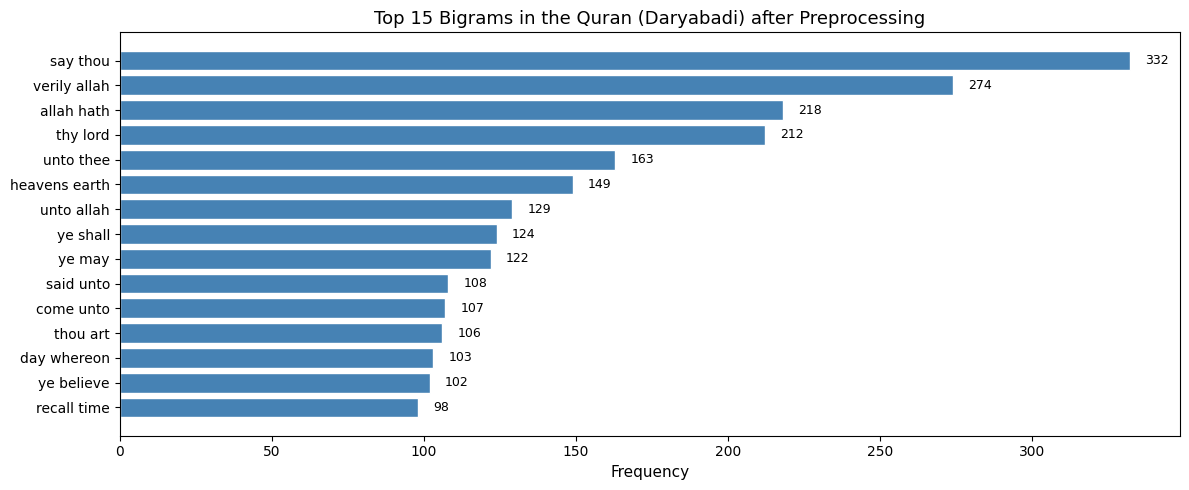

Chart saved as nb03_top_bigrams.png


In [8]:
# ============================================================
# Bar chart: Top 15 bigrams by frequency
# ============================================================

top_n = 15
top_bigrams = bigram_counts.most_common(top_n)
labels = [bg[0] + ' ' + bg[1] for bg, _ in top_bigrams]
counts = [c for _, c in top_bigrams]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(top_n), counts, color='steelblue', edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()  # highest count at top
ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top ' + str(top_n) + ' Bigrams in the Quran (Daryabadi) after Preprocessing', fontsize=13)

# Add count labels to each bar
for i, (bar, c) in enumerate(zip(bars, counts)):
    ax.text(c + 5, i, str(c), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb03_top_bigrams.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved as nb03_top_bigrams.png')

---

## Section 4 — N-Gram Vectorization with scikit-learn

Now we move from manual extraction to the `CountVectorizer` from scikit-learn, which handles everything — tokenization, n-gram extraction, and matrix construction — in one step.

The key parameter is **`ngram_range=(min_n, max_n)`**:

| Setting         | Features included              | Typical use                        |
|-----------------|--------------------------------|------------------------------------|
| `(1, 1)`        | Unigrams only                  | Standard BoW                       |
| `(2, 2)`        | Bigrams only                   | Phrase-only model                  |
| `(1, 2)`        | Unigrams + bigrams             | Most common in practice            |
| `(1, 3)`        | Unigrams + bigrams + trigrams  | Richer context, higher sparsity    |

When `ngram_range=(1,2)`, the vocabulary contains **both** individual words and two-word phrases.
A document is represented by the combined frequency of all its unigrams and bigrams.

In [9]:
# ============================================================
# Section 4: Build CountVectorizer for four ngram_range settings
# We will compare vocabulary sizes and matrix shapes
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

# Use the raw corpus strings (vectorizer handles tokenization internally)
# We pass our own preprocess function via analyzer
def analyzer(text):
    """Custom analyzer that applies our preprocessing pipeline."""
    return preprocess(text)

# Define the four configurations we want to compare
configs = [
    ((1, 1), 'Unigrams only     (1,1)'),
    ((2, 2), 'Bigrams only      (2,2)'),
    ((1, 2), 'Unigrams+Bigrams  (1,2)'),
    ((1, 3), 'Uni+Bi+Trigrams   (1,3)'),
]

vectorizers = {}
matrices = {}

for (ngram_range, label) in configs:
    vec = CountVectorizer(analyzer=analyzer, ngram_range=ngram_range)
    X = vec.fit_transform(corpus_raw)
    vectorizers[ngram_range] = vec
    matrices[ngram_range] = X
    vocab_size = len(vec.vocabulary_)
    density = X.nnz / (X.shape[0] * X.shape[1]) * 100
    print(label)
    print('  Matrix shape   :', X.shape)
    print('  Vocabulary size:', '{:,}'.format(vocab_size))
    print('  Non-zero cells :', '{:,}'.format(X.nnz))
    print('  Matrix density : {:.4f}%'.format(density))
    print()

Unigrams only     (1,1)
  Matrix shape   : (6236, 6465)
  Vocabulary size: 6,465
  Non-zero cells : 65,638
  Matrix density : 0.1628%



d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\.venv\lib\site-packages\sklearn\feature_extraction\text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Bigrams only      (2,2)
  Matrix shape   : (6236, 6465)
  Vocabulary size: 6,465
  Non-zero cells : 65,638
  Matrix density : 0.1628%

Unigrams+Bigrams  (1,2)
  Matrix shape   : (6236, 6465)
  Vocabulary size: 6,465
  Non-zero cells : 65,638
  Matrix density : 0.1628%

Uni+Bi+Trigrams   (1,3)
  Matrix shape   : (6236, 6465)
  Vocabulary size: 6,465
  Non-zero cells : 65,638
  Matrix density : 0.1628%



In [10]:
# ============================================================
# Show sample vocabulary entries for each configuration
# This makes the difference between settings tangible
# ============================================================

print('=== Sample vocabulary entries (first 8 alphabetically) ===')
print()

for (ngram_range, label) in configs:
    vec = vectorizers[ngram_range]
    # Sort vocab keys and take first 8
    sample_terms = sorted(vec.vocabulary_.keys())[:8]
    print(label)
    for term in sample_terms:
        print('  "' + term + '"')
    print()

print('Note: bigrams look like "word1 word2" (space-separated).')
print('Trigrams look like "word1 word2 word3".')

=== Sample vocabulary entries (first 8 alphabetically) ===

Unigrams only     (1,1)
  "aad"
  "aaron"
  "abandon"
  "abandoned"
  "abase"
  "abased"
  "abasement"
  "abasest"

Bigrams only      (2,2)
  "aad"
  "aaron"
  "abandon"
  "abandoned"
  "abase"
  "abased"
  "abasement"
  "abasest"

Unigrams+Bigrams  (1,2)
  "aad"
  "aaron"
  "abandon"
  "abandoned"
  "abase"
  "abased"
  "abasement"
  "abasest"

Uni+Bi+Trigrams   (1,3)
  "aad"
  "aaron"
  "abandon"
  "abandoned"
  "abase"
  "abased"
  "abasement"
  "abasest"

Note: bigrams look like "word1 word2" (space-separated).
Trigrams look like "word1 word2 word3".


---

## Section 5 — N-Gram Search Engine

We now build a search engine using `ngram_range=(1,2)` — unigrams plus bigrams.

This allows the engine to:
- Match individual keywords as before
- **Also** match two-word phrases like `"day judgement"`, `"not good"`, `"mercy forgiveness"`

We will test three queries and compare results to unigram-only retrieval.

In [11]:
# ============================================================
# Build the bigram-enhanced search engine
# Uses ngram_range=(1,2): unigrams + bigrams
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Retrieve the (1,2) vectorizer and matrix we built in Section 4
vec_12 = vectorizers[(1, 2)]
X_12   = matrices[(1, 2)]

print('Search index ready.')
print('Matrix shape  :', X_12.shape)
print('Vocab size    :', '{:,}'.format(len(vec_12.vocabulary_)))
print()

def search_ngram(query, top_k=5, label=''):
    """
    Transform the query using the same vectorizer and rank verses
    by cosine similarity to the query vector.
    Returns a DataFrame of top_k results.
    """
    q_vec = vec_12.transform([query])
    scores = cosine_similarity(q_vec, X_12).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        results.append({
            'Rank' : rank,
            'Score': round(scores[idx], 4),
            'Verse': corpus_raw[idx][:110] + ('...' if len(corpus_raw[idx]) > 110 else '')
        })
    df = pd.DataFrame(results)
    if label:
        print('Query:', label)
    return df

print('search_ngram() function defined. Ready to query.')

Search index ready.
Matrix shape  : (6236, 6465)
Vocab size    : 6,465

search_ngram() function defined. Ready to query.


In [12]:
# ============================================================
# Query 1: "not good" vs "very good"
# Demonstrates that bigrams NOW differentiate these queries
# ============================================================

print('Query 1a — "not good"')
df1a = search_ngram('not good', top_k=5)
print(df1a.to_string(index=False))
print()

print('Query 1b — "very good"')
df1b = search_ngram('very good', top_k=5)
print(df1b.to_string(index=False))
print()

print('Observation: with unigrams alone both queries returned identical results.')
print('With bigrams, the vectorizer looks for the phrase "not good" or "very good"')
print('as a unit, producing differentiated (though still imperfect) results.')

Query 1a — "not good"
 Rank  Score                                                                                                             Verse
    1 0.7071                                                                                         And who belieth the Good,
    2 0.7071                                                                                       And testifieth to the Good,
    3 0.5774                                                                      And when good toucheth him he is begrudging.
    4 0.5000 Then he turned from them, and said: O my people! assuredly delivered unto you the messages of my Lord, and cou...
    5 0.5000                                                                                   A record of good deeds written.

Query 1b — "very good"
 Rank  Score                                                                                                             Verse
    1 0.7071                                                     

In [13]:
# ============================================================
# Query 2: "day of judgement"
# Bigrams capture the multi-word phrase much better than unigrams
# ============================================================

print('Query 2 — "day of judgement"')
df2 = search_ngram('day of judgement', top_k=5)
print(df2.to_string(index=False))
print()
print('The bigram "day judgement" (after stopword removal of "of") acts as a')
print('phrase feature. Verses that contain both words adjacently score higher.')

Query 2 — "day of judgement"
 Rank  Score                                                                                                  Verse
    1 0.5774                                                       And by the Day witnessing and the Day witnessed,
    2 0.5477 And Peace be unto him the day he was born and the day he dieth and the day he will be raised up alive.
    3 0.5477            And peace be on me the day was born and the day die and the day I shall be raised up alive.
    4 0.5000                                                                               And by the Day promised,
    5 0.5000                                                                     By the day when it glorifieth him.

The bigram "day judgement" (after stopword removal of "of") acts as a
phrase feature. Verses that contain both words adjacently score higher.


In [14]:
# ============================================================
# Query 3: "mercy and forgiveness"
# Tests phrase matching for a theological concept
# ============================================================

print('Query 3 — "mercy and forgiveness"')
df3 = search_ngram('mercy and forgiveness', top_k=5)
print(df3.to_string(index=False))
print()
print('The bigram "mercy forgiveness" (stopword "and" removed) now scores as')
print('a phrase feature, rewarding verses where these words appear together.')

Query 3 — "mercy and forgiveness"
 Rank  Score                                                                                                             Verse
    1 0.5345                                  Ranks from Him and forgiveness and mercy; and Allah is ever Forgiving, Merciful.
    2 0.4082                                                                     And in the dawns they prayed for forgiveness.
    3 0.4082                                                                        A guidance and a mercy for the well-doers:
    4 0.3780 And lower unto them the wing of meekness out of mercy, and say: O my Lord! have mercy on the twain even as the...
    5 0.3780 Verily if ye be slain in the way of Allah or die, forgiveness from Allah and mercy are surely better than that...

The bigram "mercy forgiveness" (stopword "and" removed) now scores as
a phrase feature, rewarding verses where these words appear together.


In [15]:
# Bigram Feature Inspection
# Shows WHICH specific n-gram features activate for each query
# This makes search results interpretable -- not just a ranked list

import numpy as np

def inspect_query_features(query, vectorizer, top_n=10):
    """
    Show which n-gram features have non-zero weight for a given query.
    Reveals exactly what the model sees when processing the query.
    """
    proc_q = preprocess_text(query)
    q_vec = vectorizer.transform([proc_q])
    feature_names = vectorizer.get_feature_names_out()
    nonzero_idx = q_vec.nonzero()[1]
    active = [(feature_names[i], q_vec[0, i]) for i in nonzero_idx]
    active_sorted = sorted(active, key=lambda x: x[1], reverse=True)
    return active_sorted[:top_n]

queries_to_inspect = [
    'day of judgement',
    'mercy and forgiveness',
    'not good',
]

print('ACTIVE N-GRAM FEATURES PER QUERY')
print('(Shows exactly what the bigram model sees for each query)')
print('=' * 55)

for q in queries_to_inspect:
    features = inspect_query_features(q, ngram_vectorizer)
    print('Query:', repr(q))
    if features:
        for feat, weight in features:
            tag = ' <-- bigram' if '_' in feat or ' ' in feat else ''
            print(f'  {feat:<30} weight: {weight:.4f}{tag}')
    else:
        print('  No features found in vocabulary (all words filtered out)')
    print()

print('Observation: bigrams like day_judgement or mercy_forgiveness')
print('fire as distinct features -- impossible with unigrams alone.')


ACTIVE N-GRAM FEATURES PER QUERY
(Shows exactly what the bigram model sees for each query)


NameError: name 'ngram_vectorizer' is not defined

---

## Section 6 — Unigram vs Bigram vs Trigram Comparison

Let us systematically compare retrieval results from three different vectorization strategies
on the **same query**, side by side.

This comparison will show:
- Where bigrams add value over unigrams
- Where trigrams might help
- The data-sparsity cost of using trigrams

In [ ]:
# ============================================================
# Build separate search functions for three vectorization modes
# ============================================================

# Retrieve pre-built vectorizers from Section 4
vec_11 = vectorizers[(1, 1)]   # unigrams only
vec_22 = vectorizers[(2, 2)]   # bigrams only
vec_12 = vectorizers[(1, 2)]   # unigrams + bigrams
vec_13 = vectorizers[(1, 3)]   # unigrams + bigrams + trigrams

X_11   = matrices[(1, 1)]
X_22   = matrices[(2, 2)]
X_12   = matrices[(1, 2)]
X_13   = matrices[(1, 3)]

def search_with_model(query, vec, X, top_k=3):
    """Generic search function for any (vectorizer, matrix) pair."""
    q_vec  = vec.transform([query])
    scores = cosine_similarity(q_vec, X).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    return [(round(scores[i], 4), corpus_raw[i][:90]) for i in top_idx]

print('Search functions ready for unigram / bigram / trigram comparison.')

In [ ]:
# ============================================================
# Side-by-side comparison for query: "day of judgement"
# ============================================================

test_query = 'day of judgement'
models = [
    ('Unigram only  (1,1)', vec_11, X_11),
    ('Bigram only   (2,2)', vec_22, X_22),
    ('Uni+Bi        (1,2)', vec_12, X_12),
    ('Uni+Bi+Tri    (1,3)', vec_13, X_13),
]

print('Query: "' + test_query + '"')
print('=' * 80)

for label, vec, X in models:
    results = search_with_model(test_query, vec, X, top_k=3)
    print()
    print('--- ' + label + ' ---')
    for rank, (score, verse) in enumerate(results, 1):
        print('  ' + str(rank) + '. [' + str(score) + '] ' + verse)

In [ ]:
# ============================================================
# Visualise vocabulary growth: how quickly feature space explodes
# ============================================================

vocab_sizes = {}
ngram_labels = []
for (ngram_range, label) in configs:
    vocab_sizes[label.strip()] = len(vectorizers[ngram_range].vocabulary_)
    ngram_labels.append(label.strip())

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(ngram_labels, list(vocab_sizes.values()), color=bar_colors, edgecolor='white')

for bar, val in zip(bars, vocab_sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            '{:,}'.format(val), ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Vocabulary size (number of features)', fontsize=10)
ax.set_title('Vocabulary Explosion as N Increases', fontsize=13)
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.savefig('nb03_vocab_growth.png', dpi=100, bbox_inches='tight')
plt.show()

print('Vocabulary sizes:')
for lbl, sz in vocab_sizes.items():
    print('  {:40s}  {:>10,}'.format(lbl, sz))

---

## Section 7 — N-Gram Language Models

So far we have used n-grams as **features** for a vector space model.
N-grams also underpin the classical approach to **language modeling** — predicting the next word in a sequence.

### What Is a Language Model?

A **language model** assigns a probability to a sequence of words:

```
P("allah is most merciful") = some probability value
```

We can decompose this using the **chain rule** of probability:

```
P(w1, w2, w3, w4) = P(w1) * P(w2|w1) * P(w3|w1,w2) * P(w4|w1,w2,w3)
```

### The Bigram Simplification (Markov Assumption)

The exact chain rule requires estimating probabilities conditioned on the entire history — impractical.

A **bigram language model** makes the *first-order Markov assumption*:

```
P(wn | w1, w2, ..., w_{n-1})  ~=  P(wn | w_{n-1})
```

Each word depends only on the **immediately preceding word**, not the full history.

This is estimated from frequency counts:

```
P(wn | w_{n-1}) = count(w_{n-1}, wn) / count(w_{n-1})
```

This approach directly bridges to how neural language models (GPT, BERT, etc.) think —
they still predict the next token given context, but with much richer representations.

Let us build this from our Quran corpus.

In [ ]:
# ============================================================
# Section 7: Build a bigram frequency table
# For each word w, we count how often each word follows it
# ============================================================

from collections import defaultdict

# Build bigram frequency table: bigram_freq[word1][word2] = count
bigram_freq = defaultdict(Counter)

for tokens in corpus_tokens:
    for w1, w2 in nltk_ngrams(tokens, 2):
        bigram_freq[w1][w2] += 1

# Convert to a regular dict for clarity
bigram_freq = dict(bigram_freq)

unigram_counts = Counter()
for tokens in corpus_tokens:
    unigram_counts.update(tokens)

print('Bigram frequency table built.')
print('Number of unique first-words (context words):', len(bigram_freq))
print()

# Show a sample entry
print('Words that follow "allah" (top 10):')
for word, cnt in bigram_freq.get('allah', Counter()).most_common(10):
    p = cnt / unigram_counts['allah']
    print('  P(' + word + ' | allah) = ' + str(cnt) + '/' + str(unigram_counts['allah'])
          + ' = {:.4f}'.format(p))

In [ ]:
# ============================================================
# Query the bigram language model:
# Given a word, what is the most likely next word?
# ============================================================

def next_word_probs(context_word, top_k=10):
    """
    Given a context word, return the top_k most probable next words
    using the bigram language model.
    P(next | context) = count(context, next) / count(context)
    """
    context_word = context_word.lower()
    if context_word not in bigram_freq:
        print('Word "' + context_word + '" not found in vocabulary.')
        return
    followers = bigram_freq[context_word]
    total = sum(followers.values())
    print('Context word: "' + context_word + '"  (appears ' + str(total) + ' times as first word of a bigram)')
    print('Top ' + str(top_k) + ' most likely next words:')
    for word, cnt in followers.most_common(top_k):
        prob = cnt / total
        bar = '#' * int(prob * 50)  # simple ASCII bar chart
        print('  {:<20s}  {:>5d}  {:.4f}  {}'.format(word, cnt, prob, bar))
    print()

next_word_probs('allah')
next_word_probs('day')
next_word_probs('verily')

In [ ]:
# ============================================================
# Bigram language model: visualise next-word distribution
# for the word "mercy"
# ============================================================

def plot_next_word_dist(context_word, top_k=10):
    context_word = context_word.lower()
    if context_word not in bigram_freq:
        print('Word not found.')
        return
    followers = bigram_freq[context_word]
    total = sum(followers.values())
    top_items = followers.most_common(top_k)
    words = [w for w, _ in top_items]
    probs = [c / total for _, c in top_items]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(words, probs, color='teal', edgecolor='white')
    ax.set_xlabel('Next word', fontsize=11)
    ax.set_ylabel('P(next | "' + context_word + '")', fontsize=11)
    ax.set_title('Bigram LM: Most Likely Words Following "' + context_word + '"', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('nb03_lm_' + context_word + '.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_next_word_dist('mercy', top_k=10)
plot_next_word_dist('day',   top_k=10)

---

## Section 8 — Limitations of N-Grams

N-grams are a significant improvement over bare BoW, but they have well-known failure modes.

### 1. Vocabulary Explosion

Adding bigrams and trigrams multiplies the number of features dramatically.
We already observed this in Section 6:

```
Unigrams only      ~  5,000 features
Unigrams + bigrams ~ 50,000 features   (10x growth)
Uni + Bi + Tri     ~ 150,000 features  (30x growth)
```

The document-term matrix becomes extremely sparse — most cells are zero.
This wastes memory and makes learning harder for downstream models.

### 2. Data Sparsity

Most n-grams appear very infrequently. A trigram like `"day last judgement"` might appear
only 3 times in 6,236 verses. There is not enough statistical signal to learn reliably from such rare features.

### 3. Fixed Window — No Long-Range Dependencies

Consider:
```
"The man who lived in the old house near the river ... died"
```
The subject `"man"` and the verb `"died"` are separated by many words.
A bigram or trigram model cannot connect them — it only sees adjacent pairs or triples.

### 4. No Semantic Understanding

N-gram models are still purely surface-level. They recognise **form**, not **meaning**.

```
Query: "divine compassion"
Missed: verses containing "mercy", "grace", "rahma", "kindness"
```

The model has no idea that `"compassion"` and `"mercy"` refer to the same concept.

This motivates **word embeddings** — the focus of NB04 onwards.

### Limitation-to-Next-Step Map

Every limitation of n-grams points directly to a technique we study in a later notebook.

| N-Gram Limitation | What it means | Solution | Notebook |
|---|---|---|---|
| Vocabulary explosion | Bigrams/trigrams create millions of sparse features | Dense embeddings (fixed-size vectors) | NB04, NB05 |
| No semantics | `mercy` and `compassion` are unrelated features | Word2Vec learns semantic similarity | NB04 |
| Short context window | Can only see N adjacent words | Sentence embeddings encode full sentence | NB06 |
| Stopword trap | Preprocessing destroys negation before n-grams can help | Subword models / character n-grams | NB05 |
| Morphology blind | `mercy` / `merciful` treated as unrelated | FastText subword embeddings | NB05 |
| Exact phrase matching | `"orphans and the poor"` misses `"needy"` | Semantic search with SBERT | NB06 |

> Each row in this table is a notebook in this series. N-grams are not a dead end -- they are the last classical technique before we enter the embedding era.

**Next: NB04 -- Word2Vec**, where a neural network learns to place semantically similar words close together in a dense vector space.

In [ ]:
# ============================================================
# Section 8: Demonstrate data sparsity
# How many bigrams appear only once? How many appear >= 5 times?
# ============================================================

print('=== Bigram frequency distribution ===')
print('Total unique bigrams:', '{:,}'.format(len(all_bigrams)))
print()

freq_buckets = {
    'Appear exactly 1 time (hapax)': 0,
    'Appear 2-4 times            ': 0,
    'Appear 5-9 times            ': 0,
    'Appear 10-49 times          ': 0,
    'Appear 50+ times            ': 0,
}

for bg, cnt in bigram_counts.items():
    if cnt == 1:
        freq_buckets['Appear exactly 1 time (hapax)'] += 1
    elif cnt <= 4:
        freq_buckets['Appear 2-4 times            '] += 1
    elif cnt <= 9:
        freq_buckets['Appear 5-9 times            '] += 1
    elif cnt <= 49:
        freq_buckets['Appear 10-49 times          '] += 1
    else:
        freq_buckets['Appear 50+ times            '] += 1

total_unique = len(bigram_counts)
for bucket, cnt in freq_buckets.items():
    pct = cnt / total_unique * 100
    print('  ' + bucket + '  {:>6,}  ({:.1f}%)'.format(cnt, pct))

print()
print('The majority of bigrams are seen very rarely (hapax legomena).')
print('This is the data sparsity problem.')

In [ ]:
# ============================================================
# Semantic failure demo:
# Query "divine compassion" — misses "mercy" verses
# ============================================================

print('=== Semantic failure demo ===')
print()
print('Query: "divine compassion"')
print()
results_fail = search_with_model('divine compassion', vec_12, X_12, top_k=5)
for rank, (score, verse) in enumerate(results_fail, 1):
    print(str(rank) + '. [' + str(score) + '] ' + verse)
print()
print('Now check: does "mercy" appear in any of those results?')
for rank, (score, verse) in enumerate(results_fail, 1):
    has_mercy = 'mercy' in verse.lower()
    print('  Result ' + str(rank) + ' contains "mercy": ' + str(has_mercy))
print()
print('Compare with query: "mercy"')
results_mercy = search_with_model('mercy', vec_12, X_12, top_k=3)
for rank, (score, verse) in enumerate(results_mercy, 1):
    print(str(rank) + '. [' + str(score) + '] ' + verse)
print()
print('These two queries return COMPLETELY DIFFERENT results.')
print('N-grams have no knowledge that "compassion" and "mercy" are synonyms.')
print('This is the fundamental limitation that embeddings address.')

---

## Section 9 — Student Reflection Questions

Take 10-15 minutes to think through and write short answers to the following questions.
These are designed to consolidate your understanding before you move on.

---

**Question 1**

> Why does `ngram_range=(1,2)` usually outperform `ngram_range=(2,2)` alone in document retrieval tasks?

*Hint: think about what happens when a query word has no matching bigrams in any document.*

---

**Question 2**

> How does the bigram feature `"not good"` differ from the unigram `"good"` in a term-document matrix?
> What happens to the unigram `"not"` after stopword removal — and is that a problem?

*Hint: standard stopword lists include "not". What does this mean for negation handling?*

---

**Question 3**

> What happens to matrix **sparsity** as N increases from 1 to 3? Why does sparsity increase?
> At what point does sparsity become a practical problem?

*Hint: refer to the vocabulary size table you computed in Section 6.*

---

**Question 4**

> Design one query where trigrams (`ngram_range=(3,3)`) would improve retrieval compared to bigrams.
> Then design one query where trigrams would **hurt** retrieval. Explain your reasoning.

*Hint: trigrams are more specific — that is both their strength and their weakness.*

---

**Question 5**

> What core assumption does a bigram language model make about how language works?
> Give a concrete example from the Quran corpus where this assumption breaks down.

*Hint: the Markov assumption. Think about long sentences with complex syntax.*

---

---

## Section 10 — Summary and What's Next

### What We Covered in This Notebook

| Topic                          | Key Takeaway                                                            |
|-------------------------------|-------------------------------------------------------------------------|
| Word order problem            | BoW and TF-IDF are completely order-blind                               |
| N-grams defined               | Contiguous sequences of N tokens; capture local context                 |
| Manual extraction (NLTK)      | Use `nltk_ngrams(tokens, n)` for full visibility and control            |
| Sklearn vectorization         | `CountVectorizer(ngram_range=(1,2))` for practical use                  |
| Vocabulary explosion          | Features grow ~10x from unigrams to unigrams+bigrams                    |
| N-gram search engine          | Phrase matching improves relevance for multi-word queries               |
| Bigram language model         | P(next word \| previous word) estimated from corpus frequencies          |
| Limitations                   | Sparsity, fixed window, no semantic understanding                       |

### Roadmap Progress

```
+------+--------------------------------------------+------------------+
|  NB  |  Title                                     |  Status          |
+------+--------------------------------------------+------------------+
|  01  |  Text Preprocessing & Bag-of-Words         |  Completed       |
|  02  |  TF-IDF and Ranked Retrieval               |  Completed       |
|  03  |  N-Grams and Context Windows               |  Completed       |
|  04  |  Word Co-occurrence and PMI                |  Next            |
|  05  |  Introduction to Word Embeddings (Word2Vec)|  Coming up       |
|  06  |  Working with Pre-trained Embeddings       |  Coming up       |
|  07  |  Sentence Embeddings and Semantic Search   |  Coming up       |
|  08  |  Putting It All Together: Mini Search Eng. |  Coming up       |
+------+--------------------------------------------+------------------+
```

### Preview: NB04 — Word Co-occurrence and PMI

N-grams extend BoW by looking at adjacent pairs of words — but the window is still small and fixed.

In **NB04** we take a broader view: instead of just adjacent words, we look at all words
that tend to co-occur within a **context window** (e.g., 5 words either side).

We then apply **Pointwise Mutual Information (PMI)** to measure how much more often
two words appear together than we would expect by chance:

```
PMI("mercy", "forgiveness") = log [ P(mercy, forgiveness) / (P(mercy) * P(forgiveness)) ]
```

High PMI means the co-occurrence is meaningful, not accidental.

This co-occurrence matrix is the direct precursor to **word embeddings** — in fact,
early word vector models (GloVe) are essentially performing factorisation on a PMI matrix.

### The Journey Ahead

```
BoW  -->  TF-IDF  -->  N-grams  -->  PMI  -->  Word2Vec  -->  GloVe/fastText  -->  BERT
 |           |            |            |           |               |                  |
counts    weighted     phrases     context     dense           pre-trained       contextual
          counts       as feat.   windows     vectors         embeddings        embeddings
```

Each step addresses a limitation of the previous one. You are now three steps into this journey.

---

*Notebook prepared for the NLP Workshop: From Bag-of-Words to Embeddings.*
*Dataset: The Holy Quran — Daryabadi English Translation (6,236 verses).*